## 逻辑回归到Softmax回归

---

已知划分边界  
划分边界的一法向量指向正类，另一法向量指向负类；  
正类向量与法向量的余弦值为正； 负类向量与法向量的余弦值为正；  
因此，我们可以采用L1, 或者L2距离，计算两个类别  

--- 

另一种情况，我们只考虑分割边界向上的法向量；  
正类向量与法向量的余弦值为正，负类向量与法向量的余弦值为负；
这种情况下，得出sigmoid，softmax

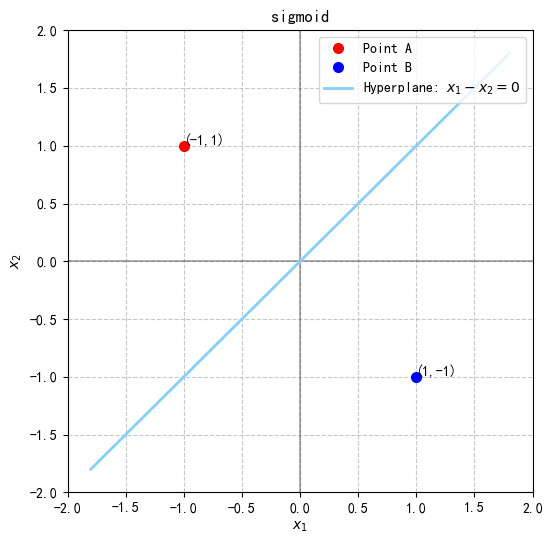

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax.grid(True, linestyle='--', alpha=0.7)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

point_a = np.array([-1, 1])
point_b = np.array([1, -1])

# 绘制点
ax.plot(point_a[0], point_a[1], 'ro', markersize=7, label='Point A')
ax.plot(point_b[0], point_b[1], 'bo', markersize=7, label='Point B')

# 绘制向量a (从原点到point_a)
# arrow_a = FancyArrow(0, 0, point_a[0], point_a[1], 
#                     width=0.02, length_includes_head=True, 
#                     color='#FF7F0E')
# ax.add_patch(arrow_a)

# arrow_b = FancyArrow(0, 0, point_b[0], point_b[1], 
#                     width=0.02, length_includes_head=True, 
#                     color='#1F77B4')
# ax.add_patch(arrow_b)

x1 = np.linspace(-1.8, 1.8, 20)
x2 = x1  # x2 = x1
ax.plot(x1, x2, color="#87CEFA", linestyle='-', linewidth=2, label='Hyperplane: $x_1-x_2=0$')
ax.text(-1,1,"(-1,1)")
ax.text(1,-1,"(1,-1)")
ax.legend(loc='upper right')
ax.set_title('sigmoid')

# 显示图形
plt.show()

## 我的

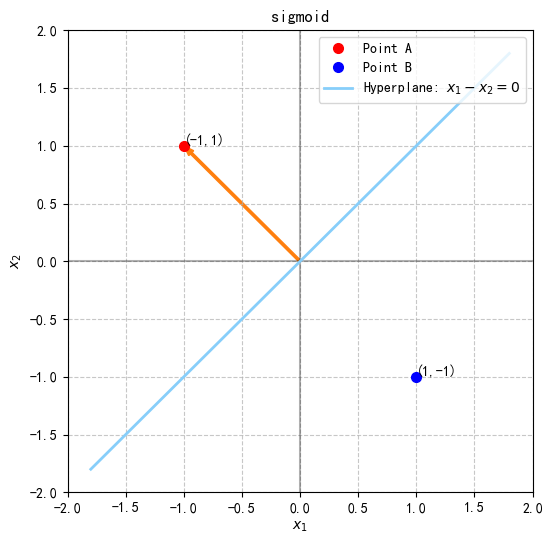

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax.grid(True, linestyle='--', alpha=0.7)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

point_a = np.array([-1, 1])
point_b = np.array([1, -1])

# 绘制点
ax.plot(point_a[0], point_a[1], 'ro', markersize=7, label='Point A')
ax.plot(point_b[0], point_b[1], 'bo', markersize=7, label='Point B')

# 绘制向量a (从原点到point_a)
arrow_a = FancyArrow(0, 0, point_a[0], point_a[1], 
                    width=0.02, length_includes_head=True, 
                    color='#FF7F0E')
ax.add_patch(arrow_a)

# arrow_b = FancyArrow(0, 0, point_b[0], point_b[1], 
#                     width=0.02, length_includes_head=True, 
#                     color='#1F77B4')
# ax.add_patch(arrow_b)

x1 = np.linspace(-1.8, 1.8, 20)
x2 = x1  # x2 = x1
ax.plot(x1, x2, color="#87CEFA", linestyle='-', linewidth=2, label='Hyperplane: $x_1-x_2=0$')
ax.text(-1,1,"(-1,1)")
ax.text(1,-1,"(1,-1)")
ax.legend(loc='upper right')
ax.set_title('sigmoid')

# 显示图形
plt.show()

## 我的，他的

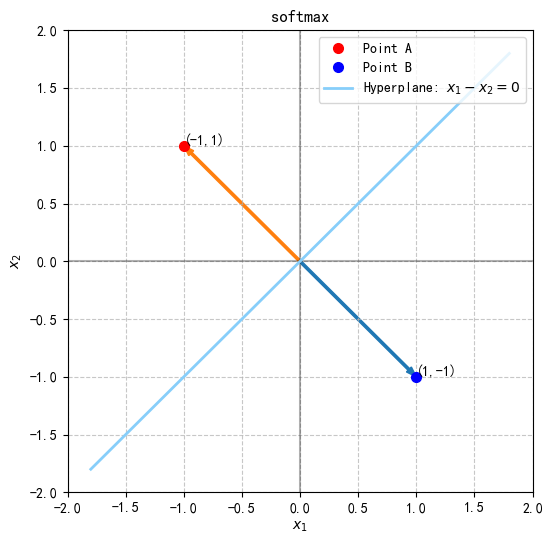

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax.grid(True, linestyle='--', alpha=0.7)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

point_a = np.array([-1, 1])
point_b = np.array([1, -1])

# 绘制点
ax.plot(point_a[0], point_a[1], 'ro', markersize=7, label='Point A')
ax.plot(point_b[0], point_b[1], 'bo', markersize=7, label='Point B')

# 绘制向量a (从原点到point_a)
arrow_a = FancyArrow(0, 0, point_a[0], point_a[1], 
                    width=0.02, length_includes_head=True, 
                    color='#FF7F0E')
ax.add_patch(arrow_a)

arrow_b = FancyArrow(0, 0, point_b[0], point_b[1], 
                    width=0.02, length_includes_head=True, 
                    color='#1F77B4')
ax.add_patch(arrow_b)

x1 = np.linspace(-1.8, 1.8, 20)
x2 = x1  # x2 = x1
ax.plot(x1, x2, color="#87CEFA", linestyle='-', linewidth=2, label='Hyperplane: $x_1-x_2=0$')
ax.text(-1,1,"(-1,1)")
ax.text(1,-1,"(1,-1)")
ax.legend(loc='upper right')
ax.set_title('softmax')

# 显示图形
plt.show()

# 度量学习

## 余弦


### 一、余弦值的“源头”：平面直角三角形中的“对边比斜边”（几何定义）
余弦值的起源完全基于**平面直角三角形的几何直观**，这是古代数学家（如古希腊、古印度、中国数学家）最早研究余弦的起点，比“向量”概念出现早了近2000年。

#### 1. 定义背景：直角三角形的边角关系
在**直角三角形**中（设一个锐角为 $\alpha$，直角为 $90^\circ$），数学家通过观察发现：对于“固定角度 $\alpha$”，其“邻边长度与斜边长度的比值”是一个**固定值**——无论三角形的大小如何缩放，这个比值只由角度 $\alpha$ 决定，与边长无关。  
于是定义：  
$$
\cos\alpha = \frac{\text{邻边}}{\text{斜边}}
$$
#### 2. 早期计算方式：几何构造与近似
古代没有计算器，余弦值的计算依赖**几何作图**和**数值近似**，核心思路是“用已知边长的直角三角形，反推角度的余弦值”：  
- 例如，要计算 $\cos30^\circ$：  
  构造一个“边长为 $1$ 的等边三角形”，将其沿高剪开，得到两个全等的直角三角形——直角边分别为“底边的一半（$0.5$）”和“高（$\sqrt{3}/2$）”，斜边为等边三角形的边长（$1$）。  
  此时锐角为 $30^\circ$，其邻边为“高（$\sqrt{3}/2$）”，斜边为 $1$，因此 $\cos30^\circ = \frac{\sqrt{3}/2}{1} = \frac{\sqrt{3}}{2} \approx 0.866$。  
- 再如，计算 $\cos45^\circ$：  
  构造“等腰直角三角形”（直角边为 $1$，斜边为 $\sqrt{2}$），锐角为 $45^\circ$，邻边与直角边相等（$1$），因此 $\cos45^\circ = \frac{1}{\sqrt{2}} \approx 0.707$。  

- 对于非特殊角（如 $25^\circ$、$67^\circ$），古代数学家会通过“作单位圆（半径为1的圆）”，将角度对应到圆上的点，再测量该点的“横坐标”（本质是邻边长度，因斜边为半径1），从而近似得到余弦值（这也是现代“单位圆定义三角函数”的雏形）。


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


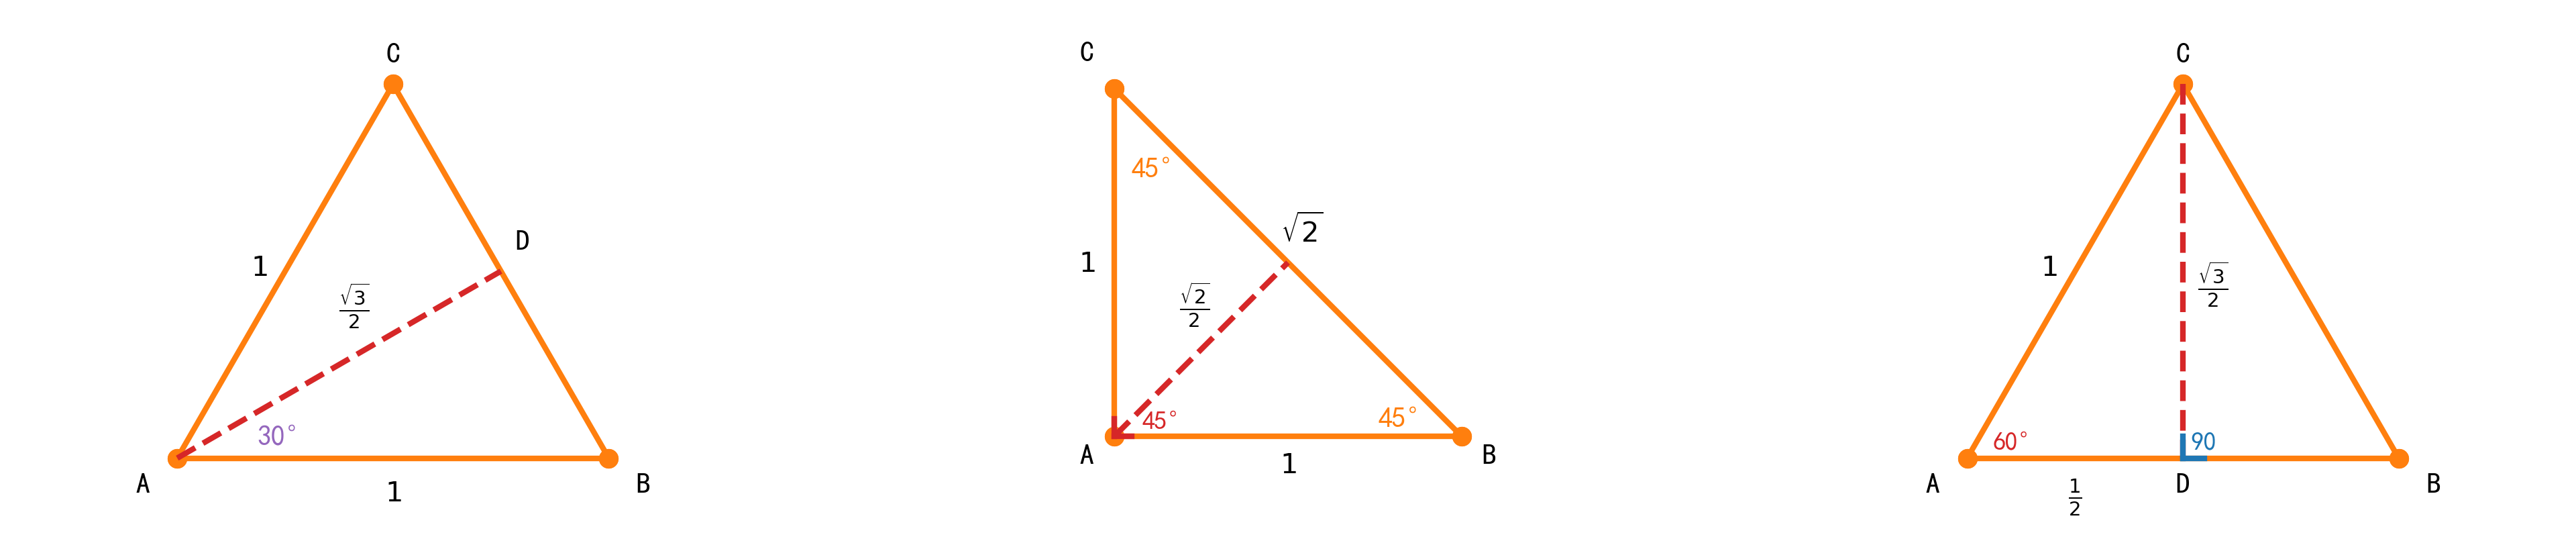

In [73]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec  # 导入GridSpec用于自定义布局

# 1. 创建3×4子图布局，设置画布大小（保证子图不拥挤）
fig = plt.figure(dpi=300, figsize=(15,10)) # 宽16英寸，高12英寸
gs = GridSpec(2, 3, width_ratios=[1, 1, 1], figure=fig)

ax00 = fig.add_subplot(gs[0, 0])

A = (0, 0)                  # 左下角顶点
B = (1, 0)                  # 右下角顶点
C = (0.5, np.sqrt(3)/2)     # 顶端顶点（高=√3/2 ≈0.866）
D = (0.5, 0)                # AB中点（剪开线的下端点，直角顶点）

ax00.plot([A[0], B[0]], [A[1], B[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='AB=1（底边）')  # AB边
ax00.plot([A[0], C[0]], [A[1], C[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='AC=1（斜边）')  # AC边
ax00.plot([B[0], C[0]], [B[1], C[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6)                        # BC边

ax00.plot([A[0], 1-1/4], [A[1], np.sqrt(3)/4], '--', color='#D62728', linewidth=2, label='CD=√3/2（高/邻边）')

right_angle_len = 0.05  # 直角符号长度

ax00.text(A[0]-0.08, A[1]-0.08, f'A', ha='center', fontsize=10, fontweight='bold')
ax00.text(B[0]+0.08, B[1]-0.08, f'B', ha='center', fontsize=10, fontweight='bold')
ax00.text(C[0], C[1]+0.05, f'C', ha='center', fontsize=10, fontweight='bold')
ax00.text(1-1/4+0.05, np.sqrt(3)/4+0.05, f'D', ha='center', fontsize=10, fontweight='bold')

ax00.text((A[0]+B[0])/2, (A[1]+B[1])/2 - 0.08, r"$1$", ha='center', va='center', fontsize=10, fontweight='bold')
ax00.text(D[0]/2-0.06, D[1]+np.sqrt(2)/4+0.09, r"$1$", ha='center',va="center",  fontsize=10, fontweight='bold')
ax00.text(D[0]-0.09, D[1]+np.sqrt(2)/4, r"$\frac{\sqrt{3}}{2}$", ha='center',va="center",  fontsize=10, fontweight='bold')

ax00.text(0.25, 0.05, '30°', fontsize=10, color='#9467BD', fontweight='bold', ha="center", va="center")

ax00.axis('equal')  # 等比例坐标轴（避免图形拉伸畸变）
ax00.set_xlim(-0.1, 1.1)  # x轴范围（留余量，避免标注超出）
ax00.set_ylim(-0.15, np.sqrt(3)/2 + 0.15)  # y轴范围
ax00.grid(True, alpha=0.3)  # 网格线（辅助观察坐标）
ax00.axis("off")
######################################################################################################
ax01 = fig.add_subplot(gs[0, 1])  # 对应第2行第1列子图（索引[1,0]）

A = (0, 0)                  # 直角顶点（原点）
B = (1, 0)                  # 水平直角边端点（AB=1）
C = (0, 1)                  # 垂直直角边端点（AC=1）

ax01.plot([A[0], B[0]], [A[1], B[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='AB=1（直角边/邻边）')
ax01.plot([A[0], C[0]], [A[1], C[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='AC=1（直角边）')
ax01.plot([B[0], C[0]], [B[1], C[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='BC=√2（斜边）')
ax01.plot([A[0],1/2],[A[1],1/2],  '--', color='#D62728', linewidth=2, markersize=6, label='AD=1（直角边）')
right_angle_len = 0.05  # 直角符号长度
ax01.plot([A[0], A[0]+right_angle_len], [A[1], A[1]], color='#D62728', linewidth=2)  # 水平小线段
ax01.plot([A[0], A[0]], [A[1], A[1]+right_angle_len], color='#D62728', linewidth=2)  # 垂直小线段
ax01.text(A[0]+0.08, A[1]+0.02, '45°', fontsize=9, color='#D62728', fontweight='bold')

ax01.text(A[0]-0.08, A[1]-0.08, f'A', ha='center', fontsize=10, fontweight='bold')
ax01.text(B[0]+0.08, B[1]-0.08, f'B', ha='center', fontsize=10, fontweight='bold')
ax01.text(C[0]-0.08, C[1]+0.08, f'C', ha='center', fontsize=10, fontweight='bold')

ax01.text((A[0]+B[0])/2, (A[1]+B[1])/2 - 0.08, r"$1$", ha='center', va='center', fontsize=10, fontweight='bold')
ax01.text((A[0]+C[0])/2 - 0.08, (A[1]+C[1])/2, r"$1$", ha='center', va='center', fontsize=10, fontweight='bold')
ax01.text(0.54, 0.60, r"$\sqrt{2}$", ha='center', va='center', fontsize=10, fontweight='bold')
ax01.text(0.23, 0.38, r"$\frac{\sqrt{2}}{2}$", ha='center', va='center', fontsize=10, fontweight='bold')

ax01.text(B[0]-0.16, B[1]+0.05, '45°', ha='center', va='center', fontsize=10, color='#FF7F0E', fontweight='bold')
ax01.text(C[0]+0.13, C[1]-0.23, '45°', ha='center', va='center', fontsize=10, color='#FF7F0E', fontweight='bold')

ax01.axis('equal')  # 等比例坐标轴，避免图形拉伸
ax01.set_xlim(-0.2, 1.2)  # x轴范围：留余量容纳标注
ax01.set_ylim(-0.25, 1.2)  # y轴范围：下方留空间放公式
ax01.grid(True, alpha=0.3)  # 辅助网格线
ax01.axis("off")  # 隐藏坐标轴，聚焦图形本身

######################################################################################################
ax02 = fig.add_subplot(gs[0, 2])

A = (0, 0)                  # 左下角顶点
B = (1, 0)                  # 右下角顶点
C = (0.5, np.sqrt(3)/2)     # 顶端顶点（高=√3/2 ≈0.866）
D = (0.5, 0)                # AB中点（剪开线的下端点，直角顶点）

ax02.plot([A[0], B[0]], [A[1], B[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='AB=1（底边）')  # AB边
ax02.plot([A[0], C[0]], [A[1], C[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6, label='AC=1（斜边）')  # AC边
ax02.plot([B[0], C[0]], [B[1], C[1]], 'o-', color='#FF7F0E', linewidth=2, markersize=6)                        # BC边
ax02.plot([C[0], D[0]], [C[1], D[1]], '--', color='#D62728', linewidth=2, label='CD=√3/2（高/邻边）')

right_angle_len = 0.05  # 直角符号长度
ax02.plot([D[0], D[0]+right_angle_len], [D[1], D[1]], color='#1F77B4', linewidth=2)  # 水平小线段
ax02.plot([D[0], D[0]], [D[1], D[1]+right_angle_len], color='#1F77B4', linewidth=2)  # 垂直小线段
ax02.text(D[0]+0.02, D[1]+0.02, '90', fontsize=9, color='#1F77B4')

ax02.text(A[0]-0.08, A[1]-0.08, f'A', ha='center', fontsize=10, fontweight='bold')
ax02.text(B[0]+0.08, B[1]-0.08, f'B', ha='center', fontsize=10, fontweight='bold')
ax02.text(C[0], C[1]+0.05, f'C', ha='center', fontsize=10, fontweight='bold')
ax02.text(D[0], D[1]-0.08, f'D', ha='center', fontsize=10, fontweight='bold')

ax02.text(D[0]/2, D[1]-0.09, r"$\frac{1}{2}$", ha='center',va="center",  fontsize=10, fontweight='bold')
ax02.text(D[0]/2-0.06, D[1]+np.sqrt(2)/4+0.09, r"$1$", ha='center',va="center",  fontsize=10, fontweight='bold')
ax02.text(D[0]+0.07, D[1]+np.sqrt(2)/4+0.05, r"$\frac{\sqrt{3}}{2}$", ha='center',va="center",  fontsize=10, fontweight='bold')
ax02.text(A[0]+0.06, A[1]+0.02, '60°', fontsize=9, color='#D62728', fontweight='bold')

ax02.axis('equal')  # 等比例坐标轴（避免图形拉伸畸变）
ax02.set_xlim(-0.1, 1.1)  # x轴范围（留余量，避免标注超出）
ax02.set_ylim(-0.15, np.sqrt(3)/2 + 0.15)  # y轴范围
ax02.grid(True, alpha=0.3)  # 网格线（辅助观察坐标）
ax02.axis("off")
#######################################################################################################################

# 调整画布边距：left/right/top/bottom 取值0~1（相对画布比例），默认约0.1
fig.subplots_adjust(
    left=0.08,    # 左边缘距：从默认0.1缩小到0.08
    right=0.92,   # 右边缘距：从默认0.9缩小到0.92（更靠近画布右侧）
    top=0.6,      # 上边缘距：容纳子图标题
    bottom=0.05   # 下边缘距：容纳cos公式标注（避免被画布底部遮挡）
)
# 显示图形
plt.show()

C:\Users\qingy\AppData\Local\Temp\ipykernel_25500\2749704703.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # 自动调整子图间距


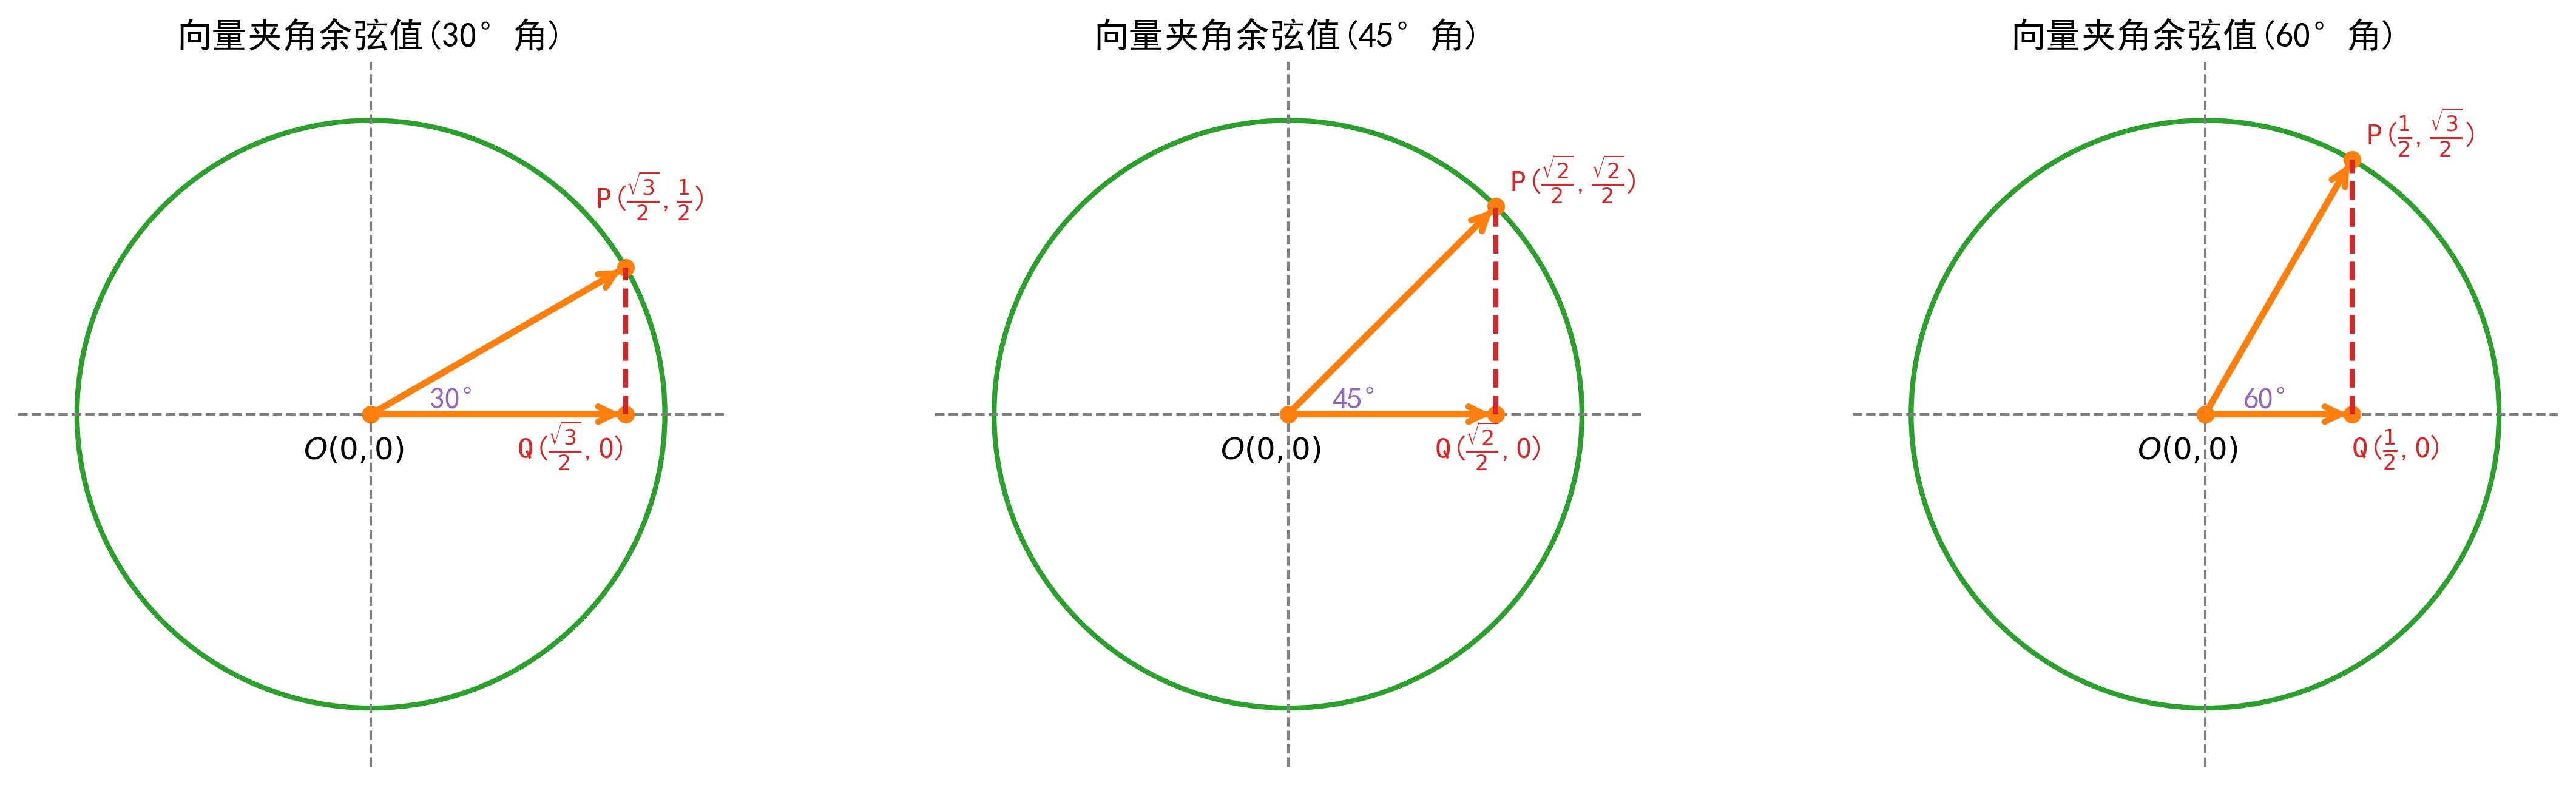

In [70]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle
from matplotlib.axes import Axes
from matplotlib.patches import Circle, FancyArrowPatch  # 导入FancyArrowPatch

# --- 全局设置 ---
# 确保中文显示正常
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题

# --- 创建图形和子图布局 ---
fig = plt.figure(dpi=300, figsize=(18, 6))  # 设置画布大小和分辨率
gs = GridSpec(1, 3, figure=fig, wspace=0.3) # 创建1行3列的布局，并设置子图间距

# --- 定义一个函数来绘制单个单位圆，避免重复代码 ---
def plot_unit_circle(ax:Axes, angle_degrees, px, py):
    # 1. 绘制单位圆
    circle = Circle((0, 0), 1, fill=False, color='#2CA02C', linestyle='-', linewidth=2, label='单位圆')
    ax.add_patch(circle)
    
    # 2. 设置坐标轴
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal', adjustable='box') # 保证x,y轴等比例，圆不变形
    ax.axhline(0, color='grey', linewidth=1, linestyle='--') # x轴
    ax.axvline(0, color='grey', linewidth=1, linestyle='--') # y轴
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_title(f'向量夹角余弦值({angle_degrees}°角)', fontsize=14, fontweight='bold')
    
    # 3. 计算角度对应的点坐标
    angle_radians = np.radians(angle_degrees)
    x = np.cos(angle_radians)
    y = np.sin(angle_radians)
    # 4. 绘制“带箭头的向量”（替代原ax.plot，终点加箭头）
    # FancyArrowPatch参数：(起点x,起点y), (终点x,终点y), 其他样式
    arrow_p = FancyArrowPatch(
        (0, 0),                # 向量起点（原点）
        (x, y),                # 向量终点（水平到x轴的(x,0)）
        color='#FF7F0E',       # 与原线段颜色一致
        linewidth=2.5,         # 与原线段线宽一致
        arrowstyle='->',       # 箭头样式（->表示“线段+箭头”）
        mutation_scale=15,     # 箭头头部大小（数值越大，箭头越粗）
        label='向量（带箭头）'  # 图例标签
    )
    ax.add_patch(arrow_p)  # 将箭头添加到子图中

    arrow_q = FancyArrowPatch(
        (0, 0),                # 向量起点（原点）
        (x, 0),                # 向量终点（水平到x轴的(x,0)）
        color='#FF7F0E',       # 与原线段颜色一致
        linewidth=2.5,         # 与原线段线宽一致
        arrowstyle='->',       # 箭头样式（->表示“线段+箭头”）
        mutation_scale=15,     # 箭头头部大小（数值越大，箭头越粗）
        label='向量（带箭头）'  # 图例标签
    )
    ax.add_patch(arrow_q)  # 将箭头添加到子图中
    
    # 4. 绘制从原点到圆上点的连线
    ax.plot([0, x], [0, y], 'o-', color='#FF7F0E', linewidth=2.5, markersize=6, label=f'终边 (cos, sin)')
    ax.plot([0, x], [0, 0], 'o-', color='#FF7F0E', linewidth=2.5, markersize=6, label=f'垂线')
    # 5. 绘制垂线 (虚线)
    # 从点(x,y)垂直下落到x轴
    ax.plot([x, x], [0, y], '--', color='#D62728', linewidth=2, label='垂线')
    
    # 6. 标注点的坐标和角度
    # 使用annotate可以更精确地控制文本位置
    dx = 0.15
    if angle_degrees == 30:
        x = x-0.15
        y = y+0.15
        dx = 0.2
    if angle_degrees == 60:
        dx = 0.13
    ax.annotate(f'P({px},{py})', xy=(x, y), xytext=(x + 0.05, y + 0.05), fontsize=12, fontweight='bold',color='#D62728')
    ax.annotate(f'Q({px},{0})', xy=(x, y), xytext=(0.5, -0.15), fontsize=12, fontweight='bold',color='#D62728')

    ax.text(dx, 0.02, f'{angle_degrees}°', fontsize=12, fontweight='bold', color='#9467BD')
    ax.text(-0.23, -0.15, r'$O(0,0)$', fontsize=12, fontweight='bold')
    ax.axis("off")
    
# --- 调用函数绘制三个子图 ---
# 30°角
ax1:Axes = fig.add_subplot(gs[0, 0])
plot_unit_circle(ax1, 30, px = r"$\frac{\sqrt{3}}{2}$", py=r"$\frac{1}{2}$")

# 45°角
ax2 = fig.add_subplot(gs[0, 1])
plot_unit_circle(ax2, 45, px = r"$\frac{\sqrt{2}}{2}$", py=r"$\frac{\sqrt{2}}{2}$")

# 60°角
ax3 = fig.add_subplot(gs[0, 2])
plot_unit_circle(ax3, 60, px = r"$\frac{1}{2}$", py=r"$\frac{\sqrt{3}}{2}$")

# --- 显示图形 ---
plt.tight_layout() # 自动调整子图间距
plt.show()



### 二、向量夹角余弦公式：余弦概念的“高维推广”
“向量夹角余弦公式”（$\cos\theta = \frac{\vec{a} \cdot \vec{b}}{|\vec{a}| \cdot |\vec{b}|}$）是19世纪后，随着**线性代数**和**高维空间理论**发展，对传统余弦概念的“扩展”——它并非余弦值的“起源”，而是将“平面直角三角形的余弦”推广到“任意维度向量”的工具。

#### 1. 推广的逻辑：从“平面角”到“向量夹角”
传统余弦只适用于“平面内的锐角/钝角”，但现实中需要处理“高维空间中两个方向（向量）的夹角”（如3维空间中两条异面直线的夹角、数据科学中100维特征向量的方向相似性）。此时“直角三角形”的几何直观失效，需要用代数方法重新定义“夹角的余弦”。

**数学家发现：**

对于平面内的两个向量 $\vec{a}$、$\vec{b}$，若用“直角三角形”的传统余弦计算它们的夹角 $\theta$，结果与“点积除以模长乘积”完全一致——这说明后者是传统余弦的“代数表达”，可以自然推广到高维空间：  

- 平面向量验证：设 $\vec{a}=(x_1,y_1)$，$\vec{b}=(x_2,y_2)$，根据传统几何，它们的夹角 $\theta$ 的余弦值可通过三角形边角关系推导；而用向量公式计算 $\frac{\vec{a} \cdot \vec{b}}{|\vec{a}| \cdot |\vec{b}|}$，结果与传统余弦值完全相同。  
- 高维推广：既然平面上成立，就可定义“n维向量的夹角余弦”为 $\frac{\vec{a} \cdot \vec{b}}{|\vec{a}| \cdot |\vec{b}|}$——这本质是用代数方法“延续”了传统余弦的核心意义（衡量方向相似性），但摆脱了“直角三角形”的几何限制。



对于平面或空间中的两个**非零向量** $\vec{a}$ 和 $\vec{b}$，设它们的夹角为 $\theta$（$0 \leq \theta \leq \pi$），则夹角余弦值 $\cos\theta$ 等于两向量的**点积**与两向量**模长乘积**的比值，公式为： 
$$
\cos\theta = \frac{\vec{a} \cdot \vec{b}}{|\vec{a}| \cdot |\vec{b}|}
$$

- **点积（内积）**：若向量用坐标表示（如 $\vec{a}=(a_1,a_2,a_3)$，$\vec{b}=(b_1,b_2,b_3)$，$n$ 为维度），则点积为对应分量乘积之和：  
  $$
  \vec{a} \cdot \vec{b} = a_1b_1 + a_2b_2 + a_3b_3
  $$
  
- **模长（长度）**：向量自身点积的平方根，反映向量的“长度”：  
  $$
  |\vec{a}| = \sqrt{a_1^2 + a_2^2 + a_3^2}, \quad |\vec{b}| = \sqrt{b_1^2 + b_2^2 + b_3^2}
  $$
  


### 总结：逻辑顺序与核心区别
- 最早的余弦值，是通过**直角三角形的邻边比斜边**（几何定义），结合作图、测量、近似计算出来的；  
- 向量夹角余弦公式，是后来为了处理高维问题，对传统余弦的“代数化改造”——它可以计算余弦值，但本质是传统余弦的推广，而非源头。  

---



### 三、特殊情况
| 向量关系       | 夹角 $\theta$ | $\cos\theta$ 值 | 示例（平面向量）          |
|----------------|--------------|----------------|---------------------------|
| 方向完全相同   | $0^\circ$    | 1              | $\vec{a}=(1,2)$，$\vec{b}=(2,4)$（$\vec{b}=2\vec{a}$） |
| 方向完全相反   | $180^\circ$  | -1             | $\vec{a}=(1,2)$，$\vec{b}=(-1,-2)$（$\vec{b}=-\vec{a}$） |
| 垂直（正交）   | $90^\circ$   | 0              | $\vec{a}=(1,0)$，$\vec{b}=(0,1)$（x轴与y轴单位向量） |
| 部分相似       | $60^\circ$   | 0.5            | $\vec{a}=(1,0)$，$\vec{b}=(0.5,\sqrt{3}/2)$ |


### 四、关键性质
夹角余弦的数学性质决定了其应用场景，核心性质如下：  
1. **取值范围**：$\cos\theta \in [-1, 1]$，且仅当两向量同向时取1，反向时取-1，垂直时取0。  
2. **与向量长度无关**：夹角余弦仅由向量“方向”决定，与向量的“长度”无关（例如 $\vec{a}=(1,2)$ 和 $\vec{b}=(2,4)$ 方向相同，$\cos\theta=1$）。  
3. **对称性**：$\cos\langle \vec{a}, \vec{b} \rangle = \cos\langle \vec{b}, \vec{a} \rangle$（两向量夹角的余弦值与顺序无关）。  
4. **非零向量前提**：若向量为零向量（模长为0），则公式分母为0，无意义，因此计算时需确保两向量均非零。





特殊情况

C:\Users\qingy\AppData\Local\Temp\ipykernel_25500\339478503.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # 自动调整子图间距


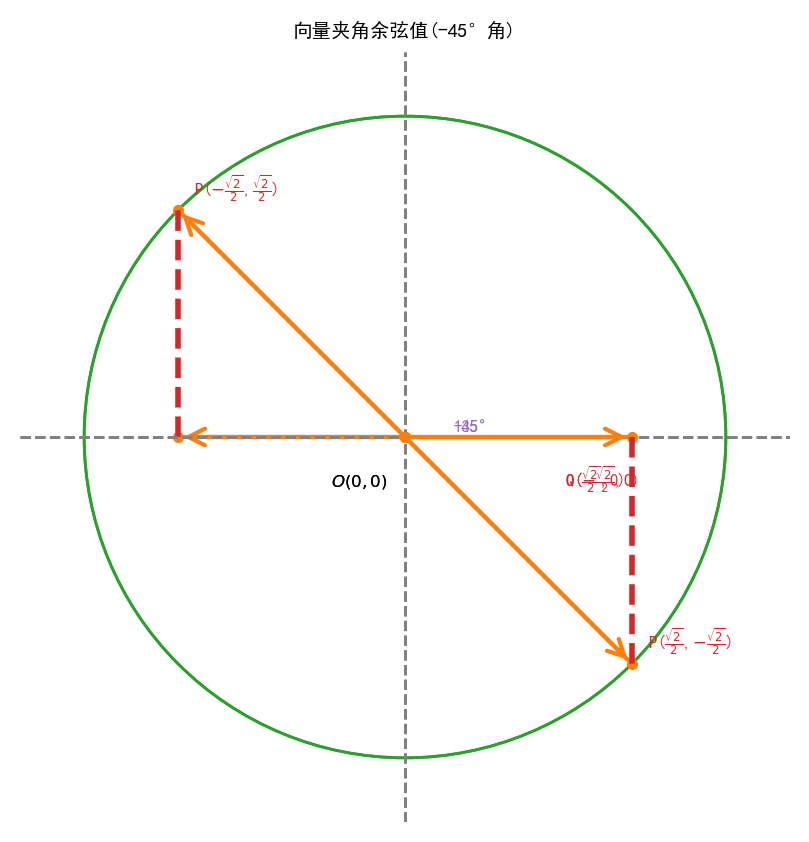

In [100]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle
from matplotlib.axes import Axes
from matplotlib.patches import Circle, FancyArrowPatch  # 导入FancyArrowPatch

# --- 全局设置 ---
# 确保中文显示正常
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题

# --- 创建图形和子图布局 ---
fig = plt.figure(dpi=200, figsize=(5, 5))  # 设置画布大小和分辨率
gs = GridSpec(1, 1, figure=fig, wspace=0.3) # 创建1行3列的布局，并设置子图间距

# --- 定义一个函数来绘制单个单位圆，避免重复代码 ---
def plot_unit_circle(ax:Axes, angle_degrees, px, py):
    # 1. 绘制单位圆
    circle = Circle((0, 0), 1, fill=False, color='#2CA02C', linestyle='-', linewidth=1, label='单位圆')
    ax.add_patch(circle)
    
    # 2. 设置坐标轴
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal', adjustable='box') # 保证x,y轴等比例，圆不变形
    ax.axhline(0, color='grey', linewidth=1, linestyle='--') # x轴
    ax.axvline(0, color='grey', linewidth=1, linestyle='--') # y轴
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_title(f'向量夹角余弦值({angle_degrees}°角)', fontsize=7, fontweight='bold')
    
    # 3. 计算角度对应的点坐标
    angle_radians = np.radians(angle_degrees)
    x = np.cos(angle_radians)
    y = np.sin(angle_radians)
    # 4. 绘制“带箭头的向量”（替代原ax.plot，终点加箭头）
    # FancyArrowPatch参数：(起点x,起点y), (终点x,终点y), 其他样式
    arrow_p = FancyArrowPatch(
        (0, 0),                # 向量起点（原点）
        (x, y),                # 向量终点（水平到x轴的(x,0)）
        color='#FF7F0E',       # 与原线段颜色一致
        linewidth=1.5,         # 与原线段线宽一致
        arrowstyle='->',       # 箭头样式（->表示“线段+箭头”）
        mutation_scale=15,     # 箭头头部大小（数值越大，箭头越粗）
        label='向量（带箭头）'  # 图例标签
    )
    ax.add_patch(arrow_p)  # 将箭头添加到子图中

    arrow_q = FancyArrowPatch(
        (0, 0),                # 向量起点（原点）
        (x, 0),                # 向量终点（水平到x轴的(x,0)）
        color='#FF7F0E',       # 与原线段颜色一致
        linewidth=1.5,         # 与原线段线宽一致
        arrowstyle='->',       # 箭头样式（->表示“线段+箭头”）
        mutation_scale=15,     # 箭头头部大小（数值越大，箭头越粗）
        label='向量（带箭头）'  # 图例标签
    )
    ax.add_patch(arrow_q)  # 将箭头添加到子图中
    
    # 4. 绘制从原点到圆上点的连线
    ax.plot([0, x], [0, y], 'o-', color='#FF7F0E', linewidth=1.5, markersize=3, label=f'终边 (cos, sin)')
    ax.plot([0, x], [0, 0], 'o-', color='#FF7F0E', linewidth=1.5, markersize=3, label=f'垂线')
    # 5. 绘制垂线 (虚线)
    # 从点(x,y)垂直下落到x轴
    ax.plot([x, x], [0, y], '--', color='#D62728', linewidth=2, label='垂线')
    
    # 6. 标注点的坐标和角度
    # 使用annotate可以更精确地控制文本位置
    dx = 0.15
    if angle_degrees == 30:
        x = x-0.15
        y = y+0.15
        dx = 0.2
    if angle_degrees == 60:
        dx = 0.13
    ax.annotate(f'P({px},{py})', xy=(x, y), xytext=(x + 0.05, y + 0.05), fontsize=6, fontweight='bold',color='#D62728')
    ax.annotate(f'Q({px},{0})', xy=(x, y), xytext=(0.5, -0.15), fontsize=6, fontweight='bold',color='#D62728')

    ax.text(dx, 0.02, f'{angle_degrees}°', fontsize=6, fontweight='bold', color='#9467BD')
    ax.text(-0.23, -0.15, r'$O(0,0)$', fontsize=6, fontweight='bold')
    ax.axis("off")
    
# --- 调用函数绘制三个子图 ---
# 30°角
ax1:Axes = fig.add_subplot(gs[0, 0])
plot_unit_circle(ax1, 135, px = r"$-\frac{\sqrt{2}}{2}$", py=r"$\frac{\sqrt{2}}{2}$")

# 45°角
# ax1 = fig.add_subplot(gs[0, 1])
plot_unit_circle(ax1, -45, px = r"$\frac{\sqrt{2}}{2}$", py=r"$-\frac{\sqrt{2}}{2}$")

# 60°角
# ax3 = fig.add_subplot(gs[0, 2])
# plot_unit_circle(ax3, 60, px = r"$\frac{1}{2}$", py=r"$\frac{\sqrt{3}}{2}$")

# --- 显示图形 ---
plt.tight_layout() # 自动调整子图间距
plt.show()

# 几何直观

D:\cache\Temp\ipykernel_28640\1562902807.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # 自动调整子图间距


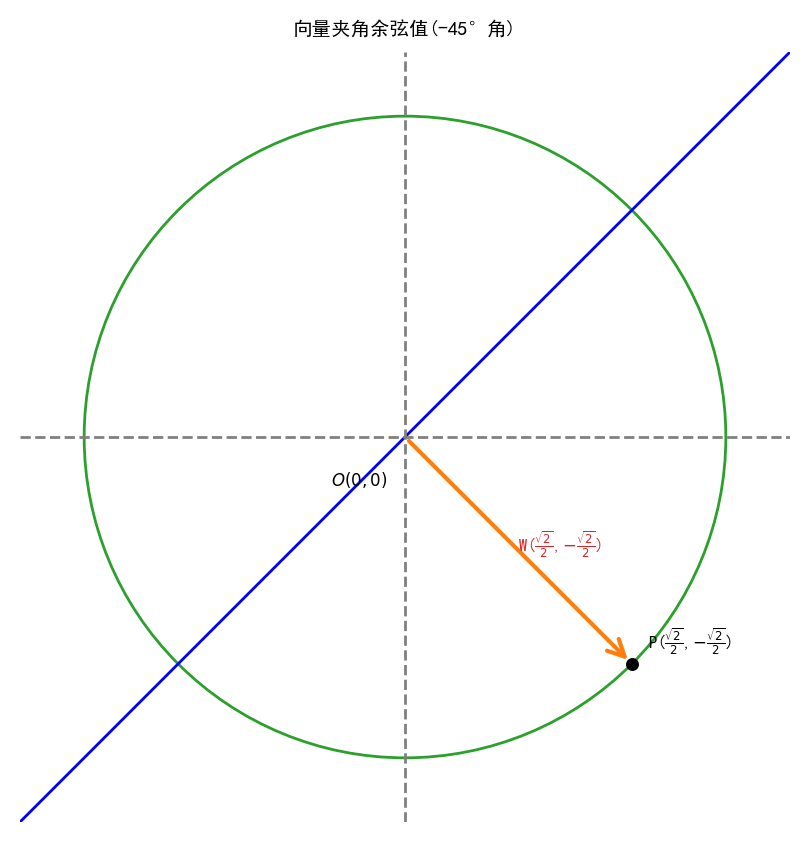

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle
from matplotlib.axes import Axes
from matplotlib.patches import Circle, FancyArrowPatch  # 导入FancyArrowPatch

plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题

fig = plt.figure(dpi=200, figsize=(5, 5))  # 设置画布大小和分辨率
gs = GridSpec(1, 1, figure=fig, wspace=0.3) # 创建1行3列的布局，并设置子图间距

def plot_unit_circle(ax:Axes, angle_degrees, px, py):
    # 1. 绘制单位圆
    circle = Circle((0, 0), 1, fill=False, color='#2CA02C', linestyle='-', linewidth=1, label='单位圆')
    ax.add_patch(circle)
    
    # 2. 设置坐标轴
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal', adjustable='box') # 保证x,y轴等比例，圆不变形
    ax.axhline(0, color='grey', linewidth=1, linestyle='--') # x轴
    ax.axvline(0, color='grey', linewidth=1, linestyle='--') # y轴
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_title(f'向量夹角余弦值({angle_degrees}°角)', fontsize=7, fontweight='bold')
    
    # 3. 计算角度对应的点坐标
    angle_radians = np.radians(angle_degrees)
    x = np.cos(angle_radians)
    y = np.sin(angle_radians)
    # 4. 绘制“带箭头的向量”（替代原ax.plot，终点加箭头）
    arrow_p = FancyArrowPatch(
        (0, 0),                # 向量起点（原点）
        (x, y),                # 向量终点（水平到x轴的(x,0)）
        color='#FF7F0E',       # 与原线段颜色一致
        linewidth=1.5,         # 与原线段线宽一致
        arrowstyle='->',       # 箭头样式（->表示“线段+箭头”）
        mutation_scale=15,     # 箭头头部大小（数值越大，箭头越粗）
        label='向量（带箭头）'  # 图例标签
    )
    ax.add_patch(arrow_p)  # 将箭头添加到子图中

    # 4. 绘制从原点到圆上点的连线
    ax.scatter(x, y, 10, color='black', linewidth=1.5, label=f'终边 (cos, sin)')
    ax.annotate(f'P({px},{py})', xy=(x, y), xytext=(x + 0.05, y + 0.05), fontsize=6, fontweight='bold',color='black')
    ax.text(x/2, y/2, f'W({px},{py})', fontsize=6, fontweight='bold',color='#D62728')
    ax.text(-0.23, -0.15, r'$O(0,0)$', fontsize=6, fontweight='bold')
    ax.axis("off")
    
# --- 调用函数绘制三个子图 ---
# 30°角
ax1:Axes = fig.add_subplot(gs[0, 0])
# ---------------------- 2. 推导并生成分割直线 ----------------------
# 分割直线的本质：满足 x·W = 0 的所有点 (x1, x2) 的集合（分类边界）
# 展开推导：w1*x1 + w2*x2 = 0 → (√2/2)x1 + (-√2/2)x2 = 0 → x1 = x2
# 生成分割直线的x1和x2数据（取合适的范围，保证图表美观）
x_range = np.linspace(-2, 2, 100)  # 生成-2到2之间的100个均匀点
decision_boundary_y = x_range  # 分割直线：x2 = x1

# ---------------------- 4. 绘制各类元素 ----------------------
# 绘制分割直线
ax1.plot(x_range, decision_boundary_y, 'b-', linewidth=1, label=f'分割直线（x·W=0）\n方程：x2 = x1')
plot_unit_circle(ax1, -45, px = r"$\frac{\sqrt{2}}{2}$", py=r"$-\frac{\sqrt{2}}{2}$")

plt.tight_layout() # 自动调整子图间距
plt.show()

## 二、Logistic回归

### 1. 输入与权重
- 特征向量 $ x = [\frac{\sqrt{2}}{2}, -\frac{\sqrt{2}}{2}] $（1×2行向量）
- 权重向量 $ W = [\frac{\sqrt{2}}{2}, -\frac{\sqrt{2}}{2}]^T $（2×1列向量，即 $ x $ 的转置）
- 线性变换：$ z = x \cdot W = (\frac{\sqrt{2}}{2} \times \frac{\sqrt{2}}{2}) + (-\frac{\sqrt{2}}{2} \times -\frac{\sqrt{2}}{2}) = \frac{2}{4} + \frac{2}{4} = 1 $

### 2. 计算概率
将线性得分 $ z=1 $ 代入Sigmoid函数：
$$
\sigma(1) = \frac{1}{1 + e^{-1}} \approx \frac{1}{1 + 0.3679} \approx 0.7311
$$
- 结果解读：该样本属于**正类（类别1）**的概率约为73.11%，属于**负类（类别0）**的概率为 $ 1 - 0.7311 = 26.89\% $


D:\cache\Temp\ipykernel_28640\2935161685.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # 自动调整子图间距


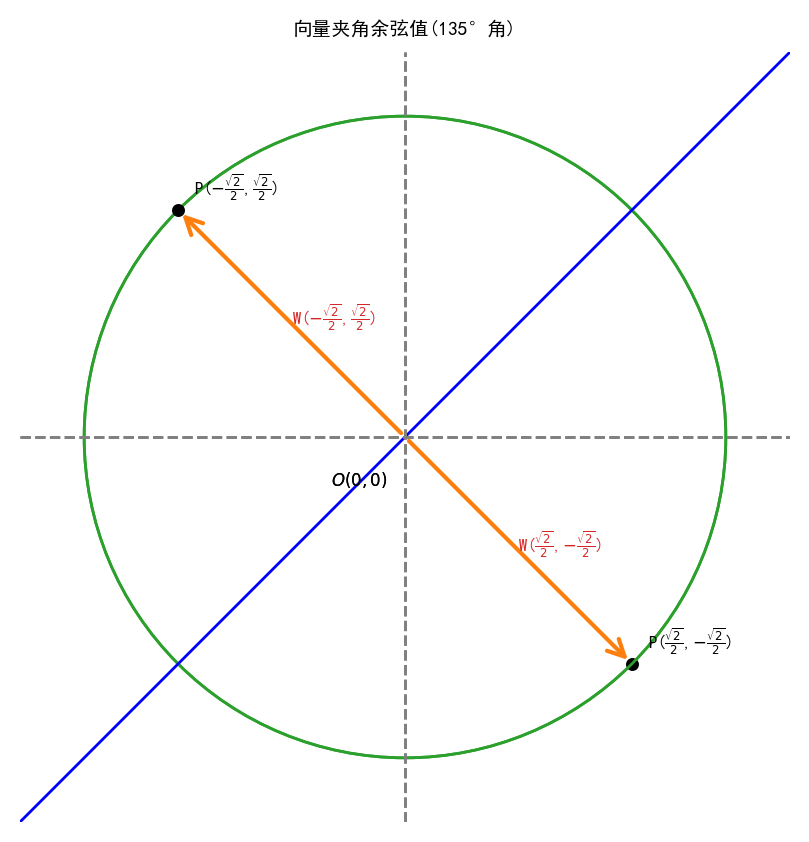

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle
from matplotlib.axes import Axes
from matplotlib.patches import Circle, FancyArrowPatch  # 导入FancyArrowPatch

plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题

fig = plt.figure(dpi=200, figsize=(5, 5))  # 设置画布大小和分辨率
gs = GridSpec(1, 1, figure=fig, wspace=0.3) # 创建1行3列的布局，并设置子图间距

def plot_unit_circle(ax:Axes, angle_degrees, px, py):
    # 1. 绘制单位圆
    circle = Circle((0, 0), 1, fill=False, color='#2CA02C', linestyle='-', linewidth=1, label='单位圆')
    ax.add_patch(circle)
    
    # 2. 设置坐标轴
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal', adjustable='box') # 保证x,y轴等比例，圆不变形
    ax.axhline(0, color='grey', linewidth=1, linestyle='--') # x轴
    ax.axvline(0, color='grey', linewidth=1, linestyle='--') # y轴
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_title(f'向量夹角余弦值({angle_degrees}°角)', fontsize=7, fontweight='bold')
    
    # 3. 计算角度对应的点坐标
    angle_radians = np.radians(angle_degrees)
    x = np.cos(angle_radians)
    y = np.sin(angle_radians)
    # 4. 绘制“带箭头的向量”（替代原ax.plot，终点加箭头）
    arrow_p = FancyArrowPatch(
        (0, 0),                # 向量起点（原点）
        (x, y),                # 向量终点（水平到x轴的(x,0)）
        color='#FF7F0E',       # 与原线段颜色一致
        linewidth=1.5,         # 与原线段线宽一致
        arrowstyle='->',       # 箭头样式（->表示“线段+箭头”）
        mutation_scale=15,     # 箭头头部大小（数值越大，箭头越粗）
        label='向量（带箭头）'  # 图例标签
    )
    ax.add_patch(arrow_p)  # 将箭头添加到子图中

    # 4. 绘制从原点到圆上点的连线
    ax.scatter(x, y, 10, color='black', linewidth=1.5, label=f'终边 (cos, sin)')
    ax.annotate(f'P({px},{py})', xy=(x, y), xytext=(x + 0.05, y + 0.05), fontsize=6, fontweight='bold',color='black')
    ax.text(x/2, y/2, f'W({px},{py})', fontsize=6, fontweight='bold',color='#D62728')
    ax.text(-0.23, -0.15, r'$O(0,0)$', fontsize=6, fontweight='bold')
    ax.axis("off")
    
# --- 调用函数绘制三个子图 ---
# 30°角
ax1:Axes = fig.add_subplot(gs[0, 0])
# ---------------------- 2. 推导并生成分割直线 ----------------------
# 分割直线的本质：满足 x·W = 0 的所有点 (x1, x2) 的集合（分类边界）
# 展开推导：w1*x1 + w2*x2 = 0 → (√2/2)x1 + (-√2/2)x2 = 0 → x1 = x2
# 生成分割直线的x1和x2数据（取合适的范围，保证图表美观）
x_range = np.linspace(-2, 2, 100)  # 生成-2到2之间的100个均匀点
decision_boundary_y = x_range  # 分割直线：x2 = x1

# ---------------------- 4. 绘制各类元素 ----------------------
# 绘制分割直线
ax1.plot(x_range, decision_boundary_y, 'b-', linewidth=1, label=f'分割直线（x·W=0）\n方程：x2 = x1')
plot_unit_circle(ax1, -45, px = r"$\frac{\sqrt{2}}{2}$", py=r"$-\frac{\sqrt{2}}{2}$")
plot_unit_circle(ax1, 135, px = r"$-\frac{\sqrt{2}}{2}$", py=r"$\frac{\sqrt{2}}{2}$")

plt.tight_layout() # 自动调整子图间距
plt.show()

## 三、Softmax回归

### 1. 输入与权重
- 特征向量 $ x = [\frac{\sqrt{2}}{2}, -\frac{\sqrt{2}}{2}] $（1×2行向量）
- 权重矩阵 $ W $（2×2矩阵，两行分别对应两个类别的权重）：
$$
W = \begin{bmatrix}
\frac{\sqrt{2}}{2} & -\frac{\sqrt{2}}{2} \\
-\frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2}
\end{bmatrix}
$$
- 线性变换：$ xW = [(\frac{\sqrt{2}}{2} \times \frac{\sqrt{2}}{2} + -\frac{\sqrt{2}}{2} \times -\frac{\sqrt{2}}{2}), (\frac{\sqrt{2}}{2} \times -\frac{\sqrt{2}}{2} + -\frac{\sqrt{2}}{2} \times \frac{\sqrt{2}}{2})] = [1, -1] $

### 2. 手动计算概率值
将线性得分 $ z = [z_1, z_2] = [1, -1] $ 代入Softmax函数：
1.  计算分子：$ e^{z_1} = e^1 \approx 2.7183 $，$ e^{z_2} = e^{-1} \approx 0.3679 $
2.  计算分母（所有类别得分的指数和）：$ e^1 + e^{-1} \approx 3.0862 $
3.  计算各类别概率：
$$
p_1 = \frac{e^1}{e^1 + e^{-1}} \approx \frac{2.7183}{3.0862} \approx 0.8808
$$
$$
p_2 = \frac{e^{-1}}{e^1 + e^{-1}} \approx \frac{0.3679}{3.0862} \approx 0.1192
$$
- 结果解读：该样本属于**类别1**的概率约为88.08%，属于**类别2**的概率约为11.92%，且 $ 0.8808 + 0.1192 = 1 $（符合多分类概率分布要求）
